In [1]:
from utils.consts import *
from utils. plotting import *
from data_reader_dfl import *
from nonlegality_analyser import *
import random

In [2]:
users = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16, 17, 18, 19, 20, 21]
dfl_reader = DataReaderDfl(DFL, users, False, limit = 500)
dfl_reader.processDataWithoutLabels()


In [3]:

path = dfl_reader.getFile()
dflAnalyser = nonLegalityAnalyser(path)
print(dflAnalyser.countActions())

type_of_action    1    3    4
userid                       
1               184  410   38
2               186  486   11
3                54  261   15
4               119  401   52
5               139  382   81
6               150  367   95
7                97  277   34
8                63  423   19
9               125  387   32
10              106  383   74
11              282  245  150
12              187  363   54
13              267  394   40
14              148  416   28
15               55  483    9
16              136  335  150
17               71  386   24
18              111  395   53
19              173  335  120
20              159  366   43
21               80  447   35


In [4]:
from RFmodel import *

User 1 is being analyzed:
CV Accuracy: 0.73 (+/- 0.06)
Test Accuracy: 0.54
1: 0.679 threshold: 0.417
User 2 is being analyzed:
CV Accuracy: 0.79 (+/- 0.08)
Test Accuracy: 0.55
2: 0.709 threshold: 0.360
User 3 is being analyzed:
CV Accuracy: 0.78 (+/- 0.11)
Test Accuracy: 0.69
3: 0.736 threshold: 0.437
User 4 is being analyzed:
CV Accuracy: 0.93 (+/- 0.05)
Test Accuracy: 0.54
4: 0.581 threshold: 0.373
User 5 is being analyzed:
CV Accuracy: 0.66 (+/- 0.10)
Test Accuracy: 0.59
5: 0.619 threshold: 0.370
User 6 is being analyzed:
CV Accuracy: 0.73 (+/- 0.07)
Test Accuracy: 0.54
6: 0.609 threshold: 0.450
User 7 is being analyzed:
CV Accuracy: 0.84 (+/- 0.10)
Test Accuracy: 0.68
7: 0.817 threshold: 0.474
User 8 is being analyzed:
CV Accuracy: 0.82 (+/- 0.07)
Test Accuracy: 0.55
8: 0.567 threshold: 0.210
User 9 is being analyzed:
CV Accuracy: 0.79 (+/- 0.08)
Test Accuracy: 0.45
9: 0.687 threshold: 0.241
User 10 is being analyzed:
CV Accuracy: 0.87 (+/- 0.07)
Test Accuracy: 0.69
10: 0.713 thres

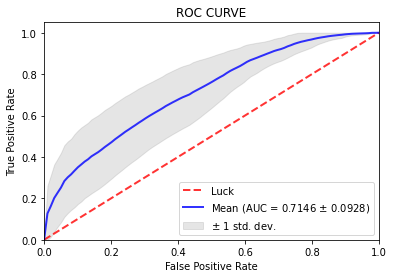

In [31]:
shuffle = True
fpr = {}
tpr = {}
roc_auc = {}
for legalUser in users:
    dataset = dflAnalyser.createTrainingDataWithLabel(legalUser)
    X = dataset[:, 0:-1]
    y = dataset[:, -1]
    X_train, X_validation, y_train, y_validation = dflAnalyser.trainingTestSplit(X, y, TEST_SIZE, shuffle)
    model = RFModel(dataset, users)
    fpr[legalUser], tpr[legalUser], thr = model.evaluate(X_train, y_train, X_validation, y_validation, scale = True, user = legalUser)
    threshold = -1
    try:
        eer = brentq(lambda x: 1. - x - interp1d(fpr[legalUser], tpr[legalUser])(x), 0., 1.) ## brentq znajdowanie 0 , interpid interpolacja
        threshold = interp1d(fpr[legalUser], thr)(eer)

    except (ZeroDivisionError, ValueError):
        print("Division by zero")

    roc_auc[legalUser] = auc(fpr[legalUser], tpr[legalUser])
    print(f"{legalUser}: {roc_auc[legalUser]:.3f} threshold: {threshold:.3f}")

plotROCs(fpr, tpr, roc_auc, users)

In [6]:
dflAnalyser = nonLegalityAnalyser(path)
print(dflAnalyser.countActions())

type_of_action    1    3    4
userid                       
1               292  414   38
2               349  483   11
3                77  262   15
4               186  400   52
5               177  380   81
6               223  369   95
7               144  276   34
8                91  423   19
9               184  400   32
10              112  383   74
11              312  246  150
12              253  362   54
13              407  394   40
14              214  417   28
15               87  484    9
16              157  336  150
17               86  387   24
18              153  399   53
19              219  334  120
20              262  374   43
21              115  447   35


User 1 is being analyzed:
CV Accuracy: 0.71 (+/- 0.07)
Test Accuracy: 0.54
1: 0.646 threshold: 0.455
User 2 is being analyzed:
CV Accuracy: 0.79 (+/- 0.05)
Test Accuracy: 0.57
2: 0.807 threshold: 0.385
User 3 is being analyzed:
CV Accuracy: 0.78 (+/- 0.12)
Test Accuracy: 0.62
3: 0.756 threshold: 0.571
User 4 is being analyzed:
CV Accuracy: 0.93 (+/- 0.05)
Test Accuracy: 0.58
4: 0.631 threshold: 0.510
User 5 is being analyzed:
CV Accuracy: 0.66 (+/- 0.11)
Test Accuracy: 0.59
5: 0.635 threshold: 0.378
User 6 is being analyzed:
CV Accuracy: 0.72 (+/- 0.06)
Test Accuracy: 0.56
6: 0.670 threshold: 0.409
User 7 is being analyzed:
CV Accuracy: 0.84 (+/- 0.08)
Test Accuracy: 0.70
7: 0.828 threshold: 0.458
User 8 is being analyzed:
CV Accuracy: 0.83 (+/- 0.09)
Test Accuracy: 0.56
8: 0.682 threshold: 0.395
User 9 is being analyzed:
CV Accuracy: 0.78 (+/- 0.09)
Test Accuracy: 0.58
9: 0.726 threshold: 0.459
User 10 is being analyzed:
CV Accuracy: 0.85 (+/- 0.05)
Test Accuracy: 0.52
10: 0.630 thres

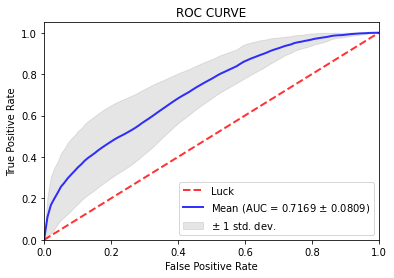

In [7]:
from RFmodel import *
shuffle = True
fpr = {}
tpr = {}
roc_auc = {}
for legalUser in users:
    dataset = dflAnalyser.createTrainingDataWithLabel(legalUser)
    X = dataset[:, 0:-1]
    y = dataset[:, -1]
    X_train, X_validation, y_train, y_validation = dflAnalyser.trainingTestSplit(X, y, TEST_SIZE, shuffle)
    model = RFModel(dataset, users)
    fpr[legalUser], tpr[legalUser], thr = model.evaluate(X_train, y_train, X_validation, y_validation, scale = True, user = legalUser)
    threshold = -1
    try:
        eer = brentq(lambda x: 1. - x - interp1d(fpr[legalUser], tpr[legalUser])(x), 0., 1.) ## brentq znajdowanie 0 , interpid interpolacja
        threshold = interp1d(fpr[legalUser], thr)(eer)

    except (ZeroDivisionError, ValueError):
        print("Division by zero")

    roc_auc[legalUser] = auc(fpr[legalUser], tpr[legalUser])
    print(f"{legalUser}: {roc_auc[legalUser]:.3f} threshold: {threshold:.3f}")

plotROCs(fpr, tpr, roc_auc, users)

User 1 is being analyzed:
CV Accuracy: 0.72 (+/- 0.07)
Test Accuracy: 0.65
1: 0.721 threshold: 0.475
User 2 is being analyzed:
CV Accuracy: 0.79 (+/- 0.06)
Test Accuracy: 0.50
2: 0.690 threshold: 0.208
User 3 is being analyzed:
CV Accuracy: 0.77 (+/- 0.11)
Test Accuracy: 0.73
3: 0.747 threshold: 0.392
User 4 is being analyzed:
CV Accuracy: 0.93 (+/- 0.05)
Test Accuracy: 0.69
4: 0.871 threshold: 0.477
User 5 is being analyzed:
CV Accuracy: 0.68 (+/- 0.06)
Test Accuracy: 0.60
5: 0.618 threshold: 0.399
User 6 is being analyzed:
CV Accuracy: 0.72 (+/- 0.08)
Test Accuracy: 0.51
6: 0.645 threshold: 0.370
User 7 is being analyzed:
CV Accuracy: 0.85 (+/- 0.05)
Test Accuracy: 0.71
7: 0.800 threshold: 0.580
User 8 is being analyzed:
CV Accuracy: 0.83 (+/- 0.09)
Test Accuracy: 0.60
8: 0.683 threshold: 0.396
User 9 is being analyzed:
CV Accuracy: 0.78 (+/- 0.05)
Test Accuracy: 0.69
9: 0.795 threshold: 0.489
User 10 is being analyzed:
CV Accuracy: 0.84 (+/- 0.07)
Test Accuracy: 0.52
10: 0.597 thres

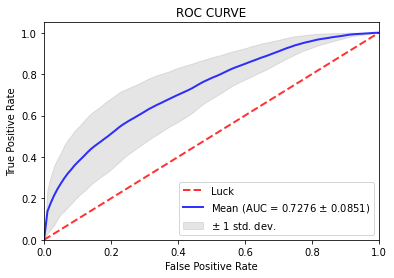

In [6]:
from RFmodel import *
shuffle = True
fpr = {}
tpr = {}
roc_auc = {}
for legalUser in users:
    dataset = dflAnalyser.createTrainingDataWithLabel(legalUser)
    X = dataset[:, 0:-1]
    y = dataset[:, -1]
    X_train, X_validation, y_train, y_validation = dflAnalyser.trainingTestSplit(X, y, TEST_SIZE, shuffle)
    model = RFModel(dataset, users)
    fpr[legalUser], tpr[legalUser], thr = model.evaluate(X_train, y_train, X_validation, y_validation, scale = True, user = legalUser)
    threshold = -1
    try:
        eer = brentq(lambda x: 1. - x - interp1d(fpr[legalUser], tpr[legalUser])(x), 0., 1.) ## brentq znajdowanie 0 , interpid interpolacja
        threshold = interp1d(fpr[legalUser], thr)(eer)

    except (ZeroDivisionError, ValueError):
        print("Division by zero")

    roc_auc[legalUser] = auc(fpr[legalUser], tpr[legalUser])
    print(f"{legalUser}: {roc_auc[legalUser]:.3f} threshold: {threshold:.3f}")

plotROCs(fpr, tpr, roc_auc, users)

User 1 is being analyzed:
CV Accuracy: 0.72 (+/- 0.05)
Test Accuracy: 0.52
1: 0.666 threshold: 0.407
User 2 is being analyzed:
CV Accuracy: 0.78 (+/- 0.04)
Test Accuracy: 0.55
2: 0.694 threshold: 0.382
User 3 is being analyzed:
CV Accuracy: 0.77 (+/- 0.14)
Test Accuracy: 0.72
3: 0.802 threshold: 0.513
User 4 is being analyzed:
CV Accuracy: 0.93 (+/- 0.05)
Test Accuracy: 0.54
4: 0.658 threshold: 0.356
User 5 is being analyzed:
CV Accuracy: 0.67 (+/- 0.08)
Test Accuracy: 0.57
5: 0.639 threshold: 0.320
User 6 is being analyzed:
CV Accuracy: 0.74 (+/- 0.04)
Test Accuracy: 0.67
6: 0.725 threshold: 0.483
User 7 is being analyzed:
CV Accuracy: 0.84 (+/- 0.07)
Test Accuracy: 0.70
7: 0.835 threshold: 0.532
User 8 is being analyzed:
CV Accuracy: 0.80 (+/- 0.09)
Test Accuracy: 0.57
8: 0.615 threshold: 0.347
User 9 is being analyzed:
CV Accuracy: 0.77 (+/- 0.08)
Test Accuracy: 0.69
9: 0.781 threshold: 0.504
User 10 is being analyzed:
CV Accuracy: 0.84 (+/- 0.07)
Test Accuracy: 0.53
10: 0.648 thres

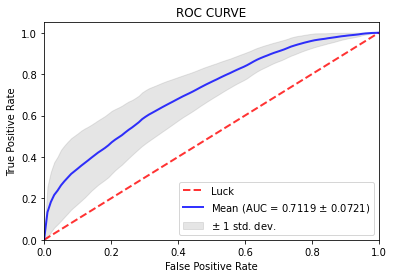

In [6]:
from RFmodel import *
shuffle = True
fpr = {}
tpr = {}
roc_auc = {}
for legalUser in users:
    dataset = dflAnalyser.createTrainingDataWithLabel(legalUser)
    X = dataset[:, 0:-1]
    y = dataset[:, -1]
    X_train, X_validation, y_train, y_validation = dflAnalyser.trainingTestSplit(X, y, TEST_SIZE, shuffle)
    model = RFModel(dataset, users)
    fpr[legalUser], tpr[legalUser], thr = model.evaluate(X_train, y_train, X_validation, y_validation, scale = True, user = legalUser)
    threshold = -1
    try:
        eer = brentq(lambda x: 1. - x - interp1d(fpr[legalUser], tpr[legalUser])(x), 0., 1.) ## brentq znajdowanie 0 , interpid interpolacja
        threshold = interp1d(fpr[legalUser], thr)(eer)

    except (ZeroDivisionError, ValueError):
        print("Division by zero")

    roc_auc[legalUser] = auc(fpr[legalUser], tpr[legalUser])
    print(f"{legalUser}: {roc_auc[legalUser]:.3f} threshold: {threshold:.3f}")

plotROCs(fpr, tpr, roc_auc, users)

User 1 is being analyzed:
CV Accuracy: 0.70 (+/- 0.09)
Test Accuracy: 0.70
NUM ACTIONS  1
1: 0.775 threshold: 0.493
User 2 is being analyzed:
CV Accuracy: 0.77 (+/- 0.06)
Test Accuracy: 0.49
NUM ACTIONS  1
2: 0.624 threshold: 0.405
User 3 is being analyzed:
CV Accuracy: 0.74 (+/- 0.12)
Test Accuracy: 0.70
NUM ACTIONS  1
3: 0.757 threshold: 0.494
User 4 is being analyzed:
CV Accuracy: 0.94 (+/- 0.05)
Test Accuracy: 0.54
NUM ACTIONS  1
4: 0.884 threshold: 0.432
User 5 is being analyzed:
CV Accuracy: 0.66 (+/- 0.07)
Test Accuracy: 0.57
NUM ACTIONS  1
5: 0.589 threshold: 0.361
User 6 is being analyzed:
CV Accuracy: 0.68 (+/- 0.09)
Test Accuracy: 0.53
NUM ACTIONS  1
6: 0.663 threshold: 0.418
User 7 is being analyzed:
CV Accuracy: 0.81 (+/- 0.06)
Test Accuracy: 0.77
NUM ACTIONS  1
7: 0.886 threshold: 0.481
User 8 is being analyzed:
CV Accuracy: 0.82 (+/- 0.10)
Test Accuracy: 0.57
NUM ACTIONS  1
8: 0.728 threshold: 0.401
User 9 is being analyzed:
CV Accuracy: 0.78 (+/- 0.11)
Test Accuracy: 0.

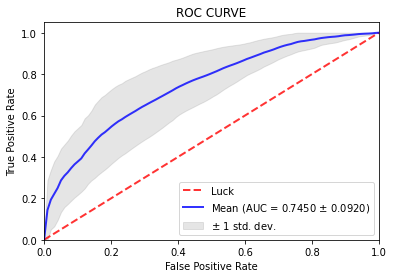

In [4]:
from RFmodel import *
shuffle = True
fpr = {}
tpr = {}
roc_auc = {}
for legalUser in users:
    dataset = dflAnalyser.createTrainingDataWithLabel(legalUser)
    X = dataset[:, 0:-1]
    y = dataset[:, -1]
    X_train, X_validation, y_train, y_validation = dflAnalyser.trainingTestSplit(X, y, TEST_SIZE, shuffle)
    model = RFModel(dataset, users)
    fpr[legalUser], tpr[legalUser], thr = model.evaluate(X_train, y_train, X_validation, y_validation, scale = True, user = legalUser)
    threshold = -1
    try:
        eer = brentq(lambda x: 1. - x - interp1d(fpr[legalUser], tpr[legalUser])(x), 0., 1.) ## brentq znajdowanie 0 , interpid interpolacja
        threshold = interp1d(fpr[legalUser], thr)(eer)

    except (ZeroDivisionError, ValueError):
        print("Division by zero")

    roc_auc[legalUser] = auc(fpr[legalUser], tpr[legalUser])
    print(f"{legalUser}: {roc_auc[legalUser]:.3f} threshold: {threshold:.3f}")

plotROCs(fpr, tpr, roc_auc, users)